# Time Series Analysis: Indexing

Imagine looking for recipes that contain cheese (or any other ingredient) in a cookbook. Instead of reading through each recipe, a list of occurrences is appended at the end - an **index**.

When comparing **huge sets** of time series, calculating the DTW or even Euclidean distance for each one is very intensive. Instead, indexing structures can help **pruning** most of the time series with very little effort. Usually, only a small fraction has to be actually searched through. This is often achieved through **tree** datastructures, where entire subtrees can be discarded during search.

This lecture shows an advanced tree indexing structure for time series - the DSTree.

In [1]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

As an index structure is made for massive amounts of data, pulling from meteostat is to extensive. Instead, we provide some simple synthetical data:

In [2]:
def generate_indexing_data(num_series, length):
    # 1. Generate random Gaussian steps
    steps = np.random.normal(loc=0.0, scale=1.0, size=(num_series, length))
    
    # 2. Cumulative sum connects the steps into a continuous random walk
    random_walks = np.cumsum(steps, axis=1)
    
    return random_walks

ts_data = generate_indexing_data(num_series=50000, length=512)

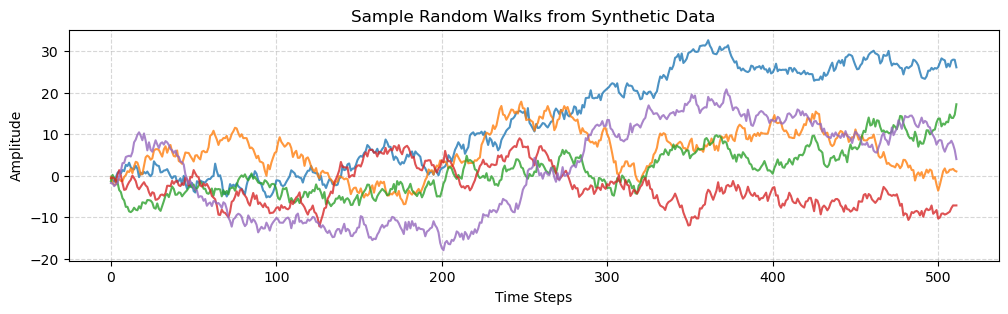

In [3]:
plt.figure(figsize=(12, 3))
plt.title("Sample Random Walks from Synthetic Data")
plt.plot(ts_data[:5, :].T, alpha=0.8, linewidth=1.5)
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## DSTree

The Dynamic Splitting Tree (DSTree) is arguably a more complex data structure than any previously shown in this course. In comparison to other indexing structures, it enforces both a **lower bound** and an **upper bound**. The upper bound allows an even better pruning. 

It uses a representation called Extended Adaptive Piecewise Constant Approximation **(EAPCA)**. Instead of only storing the mean values of the adaptive length segments (as in APCA), it stores the deviation as well. <br> Recall that PAA stores the mean for equal sized segments. APCA does not require the segments to be equal sized, allowing averaging over long segments when there is less variance and averaging short segments if there is high variance.

Based on the EAPCA, the nodes of DSTree divide the time series. When a node is full, a new split has to be found. DSTree allows two **splitting strategies**, both either by mean or deviation:
- **H-Split**: Within one of the segments use the middle between the min and max mean/deviation. Sort all time series to the according child by being above or below the new mean/deviation in that particular segment.
- **V-Split**: Split one of the segments in half. Test an H-Split in both resulting subsegments -> within the smaller subsegments split all time series either by their mean or deviation. The better performing subsegment is chose for the split.

To determine the best splitting strategy, it calculates the tightness of the resulting nodes through the distance of their lower and upper bounds. This gives a **splitting benefit**.

To track the splitting decisions, each node stores the segment bounds and for each segment a **synopsis** (lower & upper of both mean & deviation).

Only leaf nodes store the actual time series which fit to the tight bounds created over the course of the tree.

### Implementation
As with any tree, a DSTree consists of connected nodes. In the matter of object oriented programming, we split DSTree into two classes: A **DSNode and DSTree**, each handling their responsive tasks. Those tasks consist mainly of insertion and searching. How to code the DSTree is solely a design decision.

Technically, there are two types of nodes in the DSTree:
1. An inner node, which contains routing information to the children but no time series.
2. A leaf node, which contains no routing information but the respective time series.

Our combined DSNode thus contains variables for children and a splitting strategy as well as a file for time series.

A node in our DSTree implementation provides the following functionalites:
- **Splitting** into two children
- **Finding** a splitting **strategy** given its content
- **Routing** to the correct child given a query
- **Calculating** the estimation **quality** for a split
- **Searching** through its **file** for the most similar item given a query
- **Lower and upper bound** calculation of its bounds to a query

If a leaf node is full, it splits into two children and inserts the time series it holds accordingly. To do this, it first decides on a split and then calculates the resulting split for each time series, sorting them to the newly created children. The synposis of both get updated over all segments - not just the one over which the split happened.

To find the best split, it iterates over all segments and tries both splitting strategies (H- or V-Split) for both measures (mean or deviation).<br>Note that we differ from the splitting benefit of the paper, which is defined as the nodes estimation quality minus the mean of both children's estimation quality. As the nodes estimation quality is constant for the evaluation, we simply use the sum of the children's estimation quality as a splitting cost. Thus, maximizing the splitting benefit is equivalent to minimizing the splitting cost.

To route a time series to a child, it only calculates the measure on the respective splitting segment given the splitting strategy. On the resulting value, it can be routed to either the left or right child.

To calculate the estimation quality, it follows the formula provided in the paper. It basically sums the segment width times the lower-upper-bound difference over all segments.

To search for the best similarity match within its file, it simply performs a serial scan.

To calculate a lower bound, the query's mean and deviation for each segment are calculated and compared to the node's synopsis for that segment. If they are out of the segment's bounds, the difference is contributed to the lower bound distance. <br> To calculate the upper bound, each segment is evaluated for its maximum possible distance to the node's synopsis. This is done by finding the greatest distance between the query segment's mean and the extreme ends of the node's mean bounds, and combining this with the node's maximum stored standard deviation.

In [4]:
class DSNode:
    def __init__(self, max_items_per_node, ts_list=None, segmentation=None, synopsis=None):
        # Internal node has to children
        self.left = None
        self.right = None

        # Splitting Variables
        self.max_items_per_node = max_items_per_node
        self.splitting_strategy = None
        self.split_threshold = None

        # Node content
        self.file = ts_list
        self.segmentation = segmentation
        self.synopsis = synopsis

    @property
    def children(self):
        return (self.left, self.right)
    
    @property
    def count(self):
        return len(self.file)

    def is_leaf(self):
        return self.left is None and self.right is None
    
    def is_full(self):
        return len(self.file) > self.max_items_per_node
    
    def add_to_file(self, ts):
        self.file.append(ts)

    def update_synopsis(self, ts):
        # Go through each segment and calculate new measures
        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            segment = ts[l_seg:r_seg]
            s_mean = np.mean(segment)
            s_std = np.std(segment)

            self.synopsis[i]["mean_min"] = np.min([self.synopsis[i]["mean_min"], s_mean])
            self.synopsis[i]["mean_max"] = np.max([self.synopsis[i]["mean_max"], s_mean])
            self.synopsis[i]["std_min"] = np.min([self.synopsis[i]["std_min"], s_std])
            self.synopsis[i]["std_max"] = np.max([self.synopsis[i]["std_max"], s_std])

    def route_to_child(self, query):
        # 1: Fetch splitting information
        idx_seg, strategy, measure = self.splitting_strategy
        l_seg, r_seg = self.segmentation[idx_seg]

        # 2: Determine segment based on splitting strategy
        if strategy == "H_Split":
            start, end = l_seg, r_seg
        else:
            mid_seg = (l_seg + r_seg) // 2
            start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)

        # 3: Calculate the query's measure for the target segment
        val = np.mean(query[start:end]) if measure == "mean" else np.std(query[start:end])

        # 4: Route using the cached threshold
        if val < self.split_threshold:
            return self.left
        else:
            return self.right

    def create_children(self):
        # 1: Fetch splitting information
        idx_seg, strategy, measure = self.splitting_strategy
        l_seg, r_seg = self.segmentation[idx_seg]
        
        # 2: Prepare segmentation and bounds
        if strategy == "H_Split":
            new_segmentation = self.segmentation.copy()
            start, end = l_seg, r_seg
        else:
            mid_seg = (l_seg + r_seg) // 2
            new_segmentation = self.segmentation[:idx_seg] + [(l_seg, mid_seg), (mid_seg, r_seg)] + self.segmentation[idx_seg+1:]
            start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)

        # 3: Vectorized split using the cached threshold
        ts_matrix = np.array(self.file)
        target_data = ts_matrix[:, start:end]
        m_vals = np.mean(target_data, axis=1) if measure == "mean" else np.std(target_data, axis=1)
        
        left_mask = m_vals < self.split_threshold
        left_ts_matrix = ts_matrix[left_mask]
        right_ts_matrix = ts_matrix[~left_mask]

        # 4: Vectorized Synopsis creation
        left_synopsis, right_synopsis = [], []
        for l, r in new_segmentation:
            left_synopsis.append({
                "mean_min": np.min(np.mean(left_ts_matrix[:, l:r], axis=1)),
                "mean_max": np.max(np.mean(left_ts_matrix[:, l:r], axis=1)),
                "std_min": np.min(np.std(left_ts_matrix[:, l:r], axis=1)),
                "std_max": np.max(np.std(left_ts_matrix[:, l:r], axis=1)),
            })
            right_synopsis.append({
                "mean_min": np.min(np.mean(right_ts_matrix[:, l:r], axis=1)),
                "mean_max": np.max(np.mean(right_ts_matrix[:, l:r], axis=1)),
                "std_min": np.min(np.std(right_ts_matrix[:, l:r], axis=1)),
                "std_max": np.max(np.std(right_ts_matrix[:, l:r], axis=1)),
            })

        # 5: Create children
        self.left = DSNode(self.max_items_per_node, left_ts_matrix.tolist(), new_segmentation, left_synopsis)
        self.right = DSNode(self.max_items_per_node, right_ts_matrix.tolist(), new_segmentation, right_synopsis)

        # 6: Free memory
        self.file = None

    def _calculate_qos(self, ts_matrix, segmentation):
        # Handle empty node
        if len(ts_matrix) == 0:
            return 0
        
        estimation_quality = 0
        for l_seg, r_seg in segmentation:
            seg_data = ts_matrix[:, l_seg:r_seg]
            
            # Extract components for QoS: max_mean, min_mean, max_std
            mean_vals = np.mean(seg_data, axis=1)
            std_vals = np.std(seg_data, axis=1)
            
            # Estimation quality formula
            bound_tightness = (np.max(mean_vals) - np.min(mean_vals))**2 + np.max(std_vals)**2
            estimation_quality += (r_seg - l_seg) * bound_tightness
            
        return estimation_quality

    def find_best_split(self):
        # 1: Preparation
        ts_matrix = np.array(self.file)
        strategies = ["H_Split", "V_Split_Left", "V_Split_Right"]
        measures = ["mean", "std"]
        
        best_splitting_cost = np.inf

        # 2: Evaluate all possible splitting strategies across all segments
        for idx_seg, (l_seg, r_seg) in enumerate(self.segmentation):
            for strategy in strategies:
                for measure in measures:
                    
                    # 2.1: Determine the refined segmentation and target slicing bounds
                    if strategy == "H_Split":
                        new_segmentation = self.segmentation.copy()
                        start, end = l_seg, r_seg
                    else:
                        mid_seg = (l_seg + r_seg) // 2
                        new_segmentation = self.segmentation[:idx_seg] + [(l_seg, mid_seg), (mid_seg, r_seg)] + self.segmentation[idx_seg+1:]
                        start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)
                    
                    # 2.2: Compute the target measure to find the split threshold
                    target_data = ts_matrix[:, start:end]
                    if measure == "mean":
                        m_vals = np.mean(target_data, axis=1)
                    else:
                        m_vals = np.std(target_data, axis=1)
                        
                    threshold = (np.min(m_vals) + np.max(m_vals)) / 2
                    
                    # 2.3: Simulate the split using boolean indexing (much faster than list comprehensions)
                    left_mask = m_vals < threshold
                    right_mask = ~left_mask
                    
                    left_ts_matrix = ts_matrix[left_mask]
                    right_ts_matrix = ts_matrix[right_mask]

                    # Skip dead-end splits that don't actually divide the data
                    if len(left_ts_matrix) == 0 or len(right_ts_matrix) == 0:
                        continue
                    
                    # 2.4: Compute QoS for the simulated children
                    qos_left = self._calculate_qos(left_ts_matrix, new_segmentation)
                    qos_right = self._calculate_qos(right_ts_matrix, new_segmentation)
                    # In paper: splitting_benefit = qos_current - (qos_left + qos_right) / 2
                    splitting_cost = qos_left + qos_right   
                    
                    # 2.5: Track the best strategy
                    if splitting_cost < best_splitting_cost:
                        best_splitting_cost = splitting_cost
                        self.splitting_strategy = (idx_seg, strategy, measure)
                        self.split_threshold = threshold

    def calc_min_dist(self, query):        
        best_dist = np.inf
        best_ts = None

        for ts in self.file:
            # Using euclidean distance
            dist = np.linalg.norm(ts - query)

            if dist < best_dist:
                best_dist = dist
                best_ts = ts

        return best_ts, best_dist
    
    def lower_bound(self, query):
        lower_bound_sq = 0.0
        
        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            syn = self.synopsis[i]
            segment = query[l_seg:r_seg]
            
            # 1: Calculate query segment statistics
            q_mean = np.mean(segment)
            q_std = np.std(segment)

            # 2: Calculate squared distance to the synopsis bounding box
            lb_mean = (q_mean - np.clip(q_mean, syn["mean_min"], syn["mean_max"])) ** 2
            lb_std  = (q_std  - np.clip(q_std,  syn["std_min"],  syn["std_max"]))  ** 2
            
            # 3: Accumulate the weighted segment penalty
            lower_bound_sq += (r_seg - l_seg) * (lb_mean + lb_std)

        return np.sqrt(lower_bound_sq)
    
    def upper_bound(self, query):
        upper_bound_sq = 0.0

        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            syn = self.synopsis[i]
            segment = query[l_seg:r_seg]

            # 1: Calculate query statisitics on segment
            q_mean = np.mean(segment)
            q_std = np.std(segment)
            
            # 2: Upper bound for mean (max distance to endpoints) and accounting for deviation
            dist_to_min = abs(q_mean - syn["mean_min"])
            dist_to_max = abs(q_mean - syn["mean_max"])
            ub_mean = max(dist_to_min, dist_to_max) ** 2

            ub_std = (syn["std_max"] + q_std) ** 2

            # 3: Sum for segment is segment width * maximum distance
            upper_bound_sq += (r_seg - l_seg) * (ub_mean + ub_std)

        return np.sqrt(upper_bound_sq)

The DSTree class provides the three functions described in the paper:
1. **Insert**: Inserting a time series correctly into the tree.
2. **Exact search**: Finding the most similar time series to a query.
3. **Histogram**: Building a distance histogram of all time series to a query.

For insertion, the algorithm recursively traverses the tree to find the correct leaf node for the time series. Each step, the respective node's synopsis gets updated to accord for the new time series. When a leaf node is reached the time series gets inserted. <br> This can make the node reach its maximum items threshold, which initializes a split into two children.

To search for the most similar time series, a heuristic routing down the tree is applied: Routing to the child that matches the queries EAPCA. Note that this node does not have to contain the best match, as a time series in a neighboring branch with a similar EAPCA might ultimately have a smaller Euclidean distance once the exact calculation is performed. <br> From the returned leaf node, a best-so-far similarity match can be extracted. Then, the nodes of the tree are evaluated thoroughly. By computing the lower bound to the EAPCA of a node, a lot of nodes can be dropped before expensive calculations. Only where the time series is within the nodes EAPCA, a serial scan is performed.

The synopses of the nodes allows the creation of a histogram. This histogram shows the distance distribution of all indexed time series to the query. As the lower (upper) bound of children nodes can be smaller (larger) than the parents, the tightest lower (upper) bound needs to be tracked. This can happen as a parent's synopsis consists of the combined time series of both children - which can shift the mean or deviation in respect to the child. <br> The leafs information - number of time series, min and max distance to query - are stored and a histogram can be build. Specifically, the the bounds in place of actual distance calculations are sufficient. A uniform distribution is assumed.

In [5]:
import heapq

class DSTree:
    def __init__(self, max_items_per_node):
        self.max_items_per_node = max_items_per_node
        self.root = None

    def insert(self, ts):
        if self.root is None:
            # Fit root input to note structure
            self.root = DSNode(
                            max_items_per_node=self.max_items_per_node,
                            ts_list=[ts],
                            segmentation=[(0, len(ts))],
                            synopsis=[{
                                "mean_min": np.mean(ts), 
                                "mean_max": np.mean(ts), 
                                "std_min": np.std(ts), 
                                "std_max": np.std(ts)
                            }]
            )
        
        self._insert(self.root, ts)
        
    def _insert(self, node, ts):
        # 1: Update upper and lower bounds of current node to given time series
        node.update_synopsis(ts)

        # 2: Check whether current node is a leaf
        if node.is_leaf():
            # 2.1.1: If leaf reached add time series
            node.add_to_file(ts)

            # 2.1.2: If leaf is full now, split into two children
            if node.is_full():
                node.find_best_split()
                node.create_children()
        else:
            # 2.2: If not leaf yet traverse down the tree
            child = node.route_to_child(ts)
            self._insert(child, ts)

    def heuristic_search(self, query):
        # Traverse down to a leaf given query statistics
        node = self.root
        while not node.is_leaf():
            node = node.route_to_child(query)

        return node

    def exact_search(self, query):
        # 1: Perform heuristic seach of similar time series
        best_node = self.heuristic_search(query)
        best_ts, best_dist = best_node.calc_min_dist(query)
        
        # 2: Add root as entry point to priority queue of nodes possibly containing similarity match
        node_candidates = [(self.root.lower_bound(query), 0, self.root)]
        counter = 0

        # 3: Loop through nodes until all are evaluated
        while node_candidates:
            current_lb, _, current_node = heapq.heappop(node_candidates)

            # Early stop: Best candidate has too high lower bound
            if current_lb > best_dist:
                break
            
            # 3.1: Compare the best so far to best match in candidate node
            if current_node.is_leaf():
                ts, dist = current_node.calc_min_dist(query)

                if dist < best_dist:
                    best_dist = dist
                    best_ts = ts

            # 3.2: Traverse down the inner nodes
            else:
                for child_node in current_node.children:
                    child_lb = child_node.lower_bound(query)
                    
                    if child_lb < best_dist:
                        counter += 1
                        heapq.heappush(node_candidates, (child_lb, counter, child_node))
        
        return best_ts, best_dist

    def histogram(self, query, num_bins=20):
        # 1: Track statistics of leafs and nodes to be processed
        range_counts = []
        node_bounds_stack = [(self.root, -np.inf, np.inf)]

        # 2: Traverse the tree (alpha-traversal could be implemented)
        while node_bounds_stack:
            # 2.1: Enforce passing down of tight bounds
            current_node, parent_lb, parent_ub = node_bounds_stack.pop()
            
            current_lb = current_node.lower_bound(query)
            current_ub = current_node.upper_bound(query)

            tight_lb = max(parent_lb, current_lb)
            tight_ub = min(parent_ub, current_ub)

            # 2.2: Collect leaf statistics or prepare further traversal
            if current_node.is_leaf():
                count = current_node.count
                range_counts.append((tight_lb, tight_ub, count))
            else:
                for child_node in current_node.children:
                    node_bounds_stack.append((child_node, tight_lb, tight_ub))
        
        # 3: Transform gathered leaf statistics to histogram
        return self._build_histogram(range_counts, num_bins)
        
    def _build_histogram(self, range_counts, num_bins):
        # Initializing histogram structure
        min_dist = min(lb for lb, _, _ in range_counts)
        max_dist = max(ub for _, ub, _ in range_counts)
        bins = np.linspace(min_dist, max_dist, num_bins + 1)
        hist = np.zeros(num_bins)

        for lb, ub, count in range_counts:
            # Zero-width range handling
            if ub == lb:
                bin_idx = np.clip(np.digitize(lb, bins) - 1, 0, num_bins - 1)
                hist[bin_idx] += count
                continue
            
            # Assume uniform distribution
            density = count / (ub - lb)
            
            # Identify and overlay intersections between node range and current slots
            for i in range(num_bins):
                overlap = max(0, min(ub, bins[i+1]) - max(lb, bins[i]))
                hist[i] += density * overlap

        return hist, bins 


### Experiments

Let's build a tiny tree to showcase the splitting behaviour. 

The splitting strategies of the internal nodes are shown. A segment and a threshold is chosen on which the time series are 

In [6]:
# Play with the parameters
tiny_n_items = 20
tiny_max_items_per_node = 4

tiny_ds_tree = DSTree(tiny_max_items_per_node)
for ts in ts_data[:tiny_n_items, :]:
    tiny_ds_tree.insert(ts)

# Plotting the tree
def print_dstree(node, level=0, prefix=""):
    if node is None: return
        
    indent = "    " * level
    if node.is_leaf():
        print(f"{indent}{prefix}Leaf (Items: {node.count})")
    else:
        # Extract split info for internal nodes
        strat = node.splitting_strategy
        idx, strategy, measure = strat
        split_info = f"{strategy} on Seg {idx}({measure}) < {node.split_threshold:.2f}"
        
        print(f"{indent}{prefix}Internal [{split_info}]")
        
        # Recursively print children
        print_dstree(node.left, level + 1, "L--> ")
        print_dstree(node.right, level + 1, "R--> ")

print_dstree(tiny_ds_tree.root)

Internal [V_Split_Right on Seg 0(mean) < 9.64]
    L--> Internal [H_Split on Seg 1(mean) < -2.81]
        L--> Internal [V_Split_Right on Seg 0(mean) < -9.47]
            L--> Leaf (Items: 4)
            R--> Leaf (Items: 3)
        R--> Internal [H_Split on Seg 0(mean) < 0.58]
            L--> Leaf (Items: 3)
            R--> Leaf (Items: 4)
    R--> Internal [V_Split_Left on Seg 1(mean) < 33.20]
        L--> Internal [V_Split_Left on Seg 1(mean) < 12.54]
            L--> Leaf (Items: 1)
            R--> Internal [V_Split_Right on Seg 0(mean) < 15.84]
                L--> Leaf (Items: 3)
                R--> Leaf (Items: 2)
        R--> Leaf (Items: 1)


This grid visualizes the EAPCA bounds for all leaf nodes in our DSTree, with the raw time series tightly encapsulated by their respective splitting decisions. The darker blue boxes represent the bounds of the segment means, while the lighter blue areas expand these bounds by the maximum standard deviation. 

Notice how different leaves specialize in distinctly different temporal patterns and trends. This visualizes the core idea of the indeces: if a query time series falls outside these bounding boxes, the algorithm can instantly prune the entire leaf from its search without performing a single expensive distance calculation. Note that even the inner nodes contain such synopsis, which allows the pruning of entire subtrees if it doesn't match the query's EAPCA.

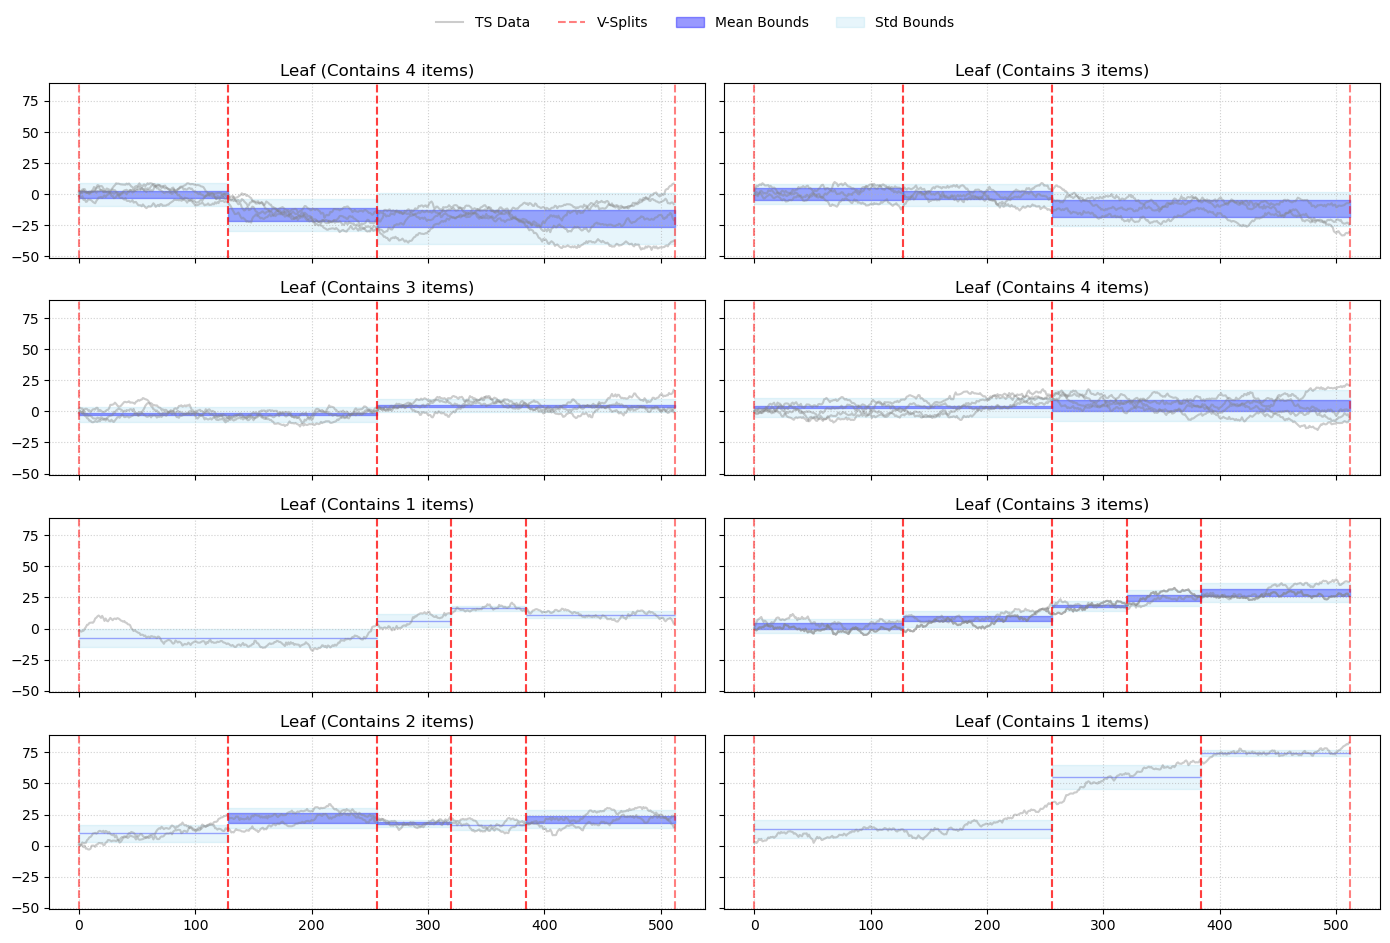

In [7]:
def get_all_leaves(node):
    if not node: return []
    return [node] if node.is_leaf() else get_all_leaves(node.left) + get_all_leaves(node.right) # Recursively traverse tree

def plot_all_leaf_synopses(tree):
    leaves = get_all_leaves(tree.root)
    
    fig, axes = plt.subplots((len(leaves) + 1) // 2, 2, figsize=(14, len(leaves) + 1), sharex=True, sharey=True)
    axes_flat = np.atleast_1d(axes).flatten()
    
    for i, (ax, node) in enumerate(zip(axes_flat, leaves)):
        lbl = lambda name: name if i == 0 else "" 
        ts_lines = ax.plot(np.array(node.file).T, color='gray', alpha=0.4) # Plot leaf items
        if i == 0 and ts_lines: ts_lines[0].set_label('TS Data')        
        
        for seg_idx, ((l, r), syn) in enumerate(zip(node.segmentation, node.synopsis)):
            ax.axvline(l, color='r', ls='--', alpha=0.5, label=lbl('V-Splits') if seg_idx == 0 else "") # Plot segment bounds created by V-Splits
            ax.axvline(r, color='r', ls='--', alpha=0.5)
            
            m_min, m_max, s_max = syn["mean_min"], syn["mean_max"], syn["std_max"]
            ax.fill_between([l, r], m_min, m_max, color='blue', alpha=0.4, label=lbl('Mean Bounds') if seg_idx == 0 else "") # Plot mean synopsis
            ax.fill_between([l, r], m_min - s_max, m_max + s_max, color='skyblue', alpha=0.2, label=lbl('Std Bounds') if seg_idx == 0 else "") # Plot std dev synopsis

        ax.set(title=f"Leaf (Contains {node.count} items)")
        ax.grid(True, ls=':', alpha=0.6)

    # 3. Cleanup unused axes and call native figure legend
    [fig.delaxes(ax) for ax in axes_flat[len(leaves):]]
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    plt.tight_layout()
    plt.show()

# Run it on the small demonstration tree
plot_all_leaf_synopses(tiny_ds_tree)

Let's build a more extensive DSTree with all our synthetic data that actually utilizes its indexing strength. 

Let's also define a serial scan algorithm for runtime comparison.

-----

We can observe that the index creation takes fairly long. However, the similarity search is faster than a serial scan. Yet both return the exact same time series.

In [8]:
ds_tree = DSTree(max_items_per_node=100)
query = ts_data[0, :]
insertion_data = ts_data[1:, :]

for ts in insertion_data:
    ds_tree.insert(ts)

In [9]:
%%time
best_ts_dstree, best_dist_dstree = ds_tree.exact_search(query)

CPU times: user 50.7 ms, sys: 16.6 ms, total: 67.3 ms
Wall time: 64.9 ms


In [10]:
def serial_search(query, target):
    best_dist = np.inf
    best_ts = []

    for ts in target:
        dist = np.linalg.norm(query - ts)
        if dist < best_dist:
            best_dist = dist
            best_ts = ts

    return best_ts, best_dist

In [11]:
%%time
best_ts_serial, best_dist_serial = serial_search(query, insertion_data)

CPU times: user 127 ms, sys: 0 ns, total: 127 ms
Wall time: 136 ms


In [12]:
print(f"The index finds the correct target: {np.allclose(best_ts_dstree, best_ts_serial)}")

The index finds the correct target: True


The DSTree provides a distance histogram given a query. You can observe how many time series in the tree are how distant to the query time series. 

We follow the paper and assume a normal distribution of distances. However, specific data might demand other distribution assumptions to accurately build the histogram.

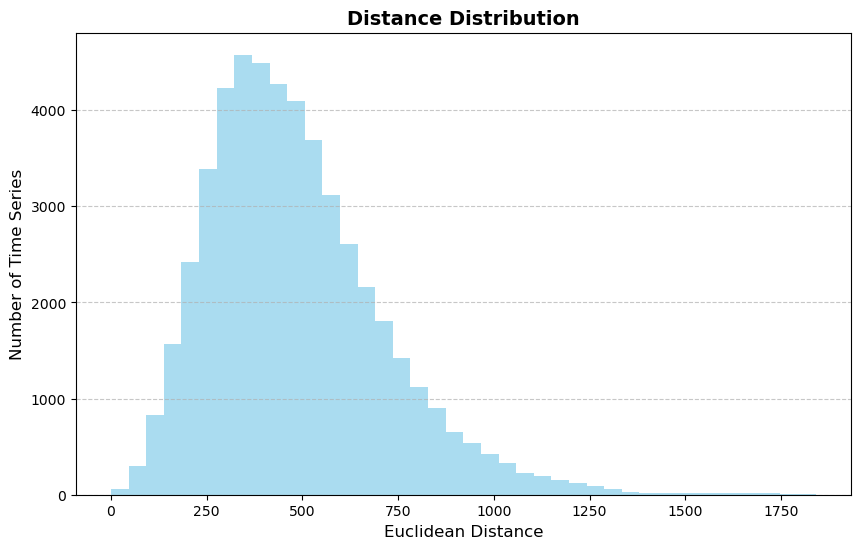

In [13]:
hist, bins = ds_tree.histogram(query, num_bins=40)
plt.figure(figsize=(10, 6))
    
# plt.stairs is perfect for pre-computed bin edges and values
plt.stairs(hist, bins, fill=True, color='skyblue', edgecolor='black', alpha=0.7)

plt.title("Distance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Euclidean Distance", fontsize=12)
plt.ylabel("Number of Time Series", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Exercises

### Data Dependence of DSTree
Build a DSTree with z-normalized data and repeat the comparison to linear search from above. You can do it manually or use `scipy.stats.zscore`. You can time the execution of the searches with putting `%%time` at the top of the cell.

You can also try more complex synthetic data. Use different synoidal shapes and stepfunctions to create complex patterns. Perform a serial scan and an index build + search on that data. Does create different runtime results?

In [14]:
znormalized_data = None
znormalized_query = None

# z_dstree = DSTree(max_items_per_node=None)
# for z_ts in znormalized_data:
#     z_dstree.insert(znormalized_data)

### Heuristic Result

Compare the result of the heuristic search to the query and exact search result.

The heuristic search only returns a node. Use the node's `_calc_min_dist()` method to find the best heuristic match. Use the trees `exact_search()` method to find the actual most similar time series.

You can plot the query and both similarity matches to find differences.

In [15]:
query = ts_data[0, :]
heuristic_node = ds_tree.heuristic_search(query)

# YOUR CODE HERE


In [16]:
# Plotting
# plt.figure(figsize=(12, 3))

# plt.plot() # Query TS
# plt.plot() # exact_search result
# plt.plot() # heuristic_search result

# plt.show()

### Faster Histogram
The authors suggest a so-called $\alpha$-level for a quicker creation of the histogram. Instead of viewing all leave nodes, it only travesers the tree to a certain height. If no leaf node is reached by then, it uses the inner nodes synopsis.

The authors describe it the following way:
>Denote by H the height of a DSTree. For each path from the root to a leaf node, we select the ⌈$\alpha$ ∗ H⌉-th internal node instead of the corresponding leaf node to generate the list L. If the length of a path is shorter than ⌈$\alpha$ ∗ H⌉, we simply use the leaf node. In other words, we use the nodes located in certain cross section of the whole tree to generate L. The histogram algorithm can be extended to this case easily. The experimental results show that we can obtain good estimation with $\frac{2}{3}$-level.
><br>Once we obtain the list L, we can compute a histogram based on it. There are multiple ways to compute a histogram. A straightforward way is to assume that the time series contained in a node are distributed uniformly.

In [17]:
alpha = 2.0/3.0

# Hints:
# 1. Calculate max tree height (H)
# 2. Determine target depth (np.ceil(alpha * H))
# 3. Traverse tree only until max depth to build range_counts in the histogram code

# YOUR CODE HERE - you can copy the DSTree class


### Better Tree Structure

The authors briefly describe two ideas to avoid unbalanced trees. The best logarithmic access can be achieved with perfectly wide, level trees. An unbalance can occur with unfortunate time series insertions, that produce a deep tree instead of a wide tree by e.g. inserting data that is highly sorted by similarity, or if a dense cluster of nearly identical time series continually forces the tree to split along the exact same segment and measure, creating a narrow, highly nested branch.

The two ideas are:
- Building several trees with different insertion orders and selecting the one with the best balance as the index.
- Adjusting the final tree by moving the deep nodes further towards the root. 

The first idea is way less complex than the second. You can define a tree selection measure (e.g. maximum height, difference between shortest and longest path, etc.) and select the trees accordingly.

You can test the runtime against the tree from above.

In [18]:
def tree_quality(tree_root):
    pass # return a quality measure

def build_balanced_tree(insertion_data, n_tries):
    pass # return the best tree

# best_tree = build_balanced_tree(None, None)

In [19]:
# %%time # runtime test
# best_tree.exact_search(query)